In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pqcd.utils import (
    to_nucleons_per_cubic_femtometre,
    nsat,
    weighted_quantile
)

In [2]:
# Load the collated EOSs
collated_eos_gp0 = pd.read_csv(
    '../data/eos-draws-default/eos-draws-default.csv',
    index_col='eos'
)

# This version has cs2max pre-computed
collated_eos_gp0_sup = pd.read_csv(
    '../data/eos-draws-default/collated_np_all_post.csv',
    index_col='eos'
)

astro_weights_gp0 = np.exp(
    collated_eos_gp0.logweight_total - collated_eos_gp0.logweight_total.max()
).values
astro_weights_gp0 /= max(astro_weights_gp0)

ntov_marg_weights_gp0 = np.loadtxt(
    '../data/eos-draws-default/pqcd-weights/pqcd_weights_ntov_marg.dat'
)

collated_eos_gp0['cs2max'] = collated_eos_gp0_sup['cs2c2max']
collated_eos_gp0['n_at_cs2max'] = to_nucleons_per_cubic_femtometre(collated_eos_gp0_sup['baryon_density(cs2c2@cs2c2max)'].values)

In [3]:
q5, q50, q95 = weighted_quantile(collated_eos_gp0['cs2max'].values, quantiles=(0.05, 0.5, 0.95), weights=astro_weights_gp0)
print(f'{q50:.2f} + {q95-q50:.2f} - {q50-q5:.2f}')

0.85 + 0.14 - 0.31


In [4]:
q5, q50, q95 = weighted_quantile(
    collated_eos_gp0['n_at_cs2max'].values/nsat,
    quantiles=(0.05, 0.5, 0.95),
    weights=astro_weights_gp0
)
print(f'{q50:.2f} + {q95-q50:.2f} - {q50-q5:.2f}')

3.71 + 2.96 - 1.71


In [5]:
q5, q50, q95 = weighted_quantile(
    collated_eos_gp0['cs2max'].values, 
    quantiles=(0.05, 0.5, 0.95), 
    weights=astro_weights_gp0*ntov_marg_weights_gp0
    )
print(f'{q50:.2f} + {q95-q50:.2f} - {q50-q5:.2f}')

0.78 + 0.22 - 0.27


In [6]:
q5, q50, q95 = weighted_quantile(
    collated_eos_gp0['n_at_cs2max'].values/nsat,
    quantiles=(0.05, 0.5, 0.95),
    weights=astro_weights_gp0*ntov_marg_weights_gp0
)
print(f'{q50:.2f} + {q95-q50:.2f} - {q50-q5:.2f}')

3.07 + 3.14 - 1.17


In [7]:
collated_eos_gp2 = pd.read_csv(
    '../data/eos-draws-modified/gp2/eos-draws-modified-gp2.csv'
)

astro_weights_gp2 = np.exp(
    collated_eos_gp2.logweight_total - collated_eos_gp2.logweight_total.max()
).values
astro_weights_gp2 /= max(astro_weights_gp2)

In [8]:
cs2max = np.loadtxt(
    '../data/eos-draws-modified/gp2/cs2max.dat',
)

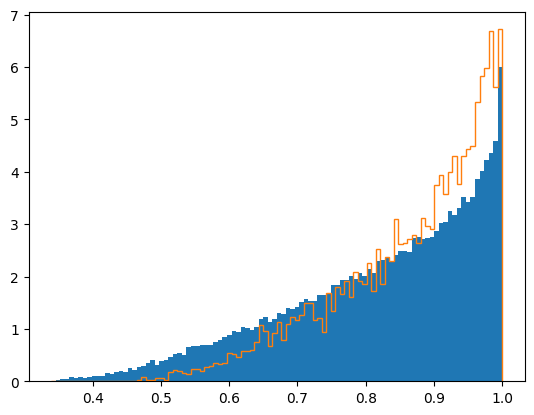

In [9]:
fig, ax = plt.subplots()
ax.hist(cs2max, bins=100, density=True)
ax.hist(cs2max, bins=100, density=True, weights=astro_weights_gp2, histtype='step');

In [10]:
weighted_quantile(cs2max, quantiles=[0.], weights=astro_weights_gp2)

array([0.33881834])

In [11]:
min(cs2max)

np.float64(0.3388183431419206)